# TMB Classification from Whole-Slide Images

This notebook performs Tumor Mutational Burden (TMB) classification from histopathology images using a CNN model.

In [ ]:
import os
import random
import gzip

import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.utils.checkpoint as checkpoint

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from timm.layers import (
    DropPath,
    to_2tuple,
    trunc_normal_
)

In [ ]:
!wget https://gdc.cancer.gov/files/public/file/gdc-client_v1.6.1_Ubuntu_x64.zip
!unzip gdc-client*.zip

--2026-05-13 00:23:53--  https://gdc.cancer.gov/files/public/file/gdc-client_v1.6.1_Ubuntu_x64.zip
Resolving gdc.cancer.gov (gdc.cancer.gov)... 3.218.21.107, 34.206.8.97
Connecting to gdc.cancer.gov (gdc.cancer.gov)|3.218.21.107|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://gdc.cancer.gov:443/system/files/public/file/gdc-client_v1.6.1_Ubuntu_x64.zip [following]
--2026-05-13 00:23:53--  https://gdc.cancer.gov/system/files/public/file/gdc-client_v1.6.1_Ubuntu_x64.zip
Reusing existing connection to gdc.cancer.gov:443.
HTTP request sent, awaiting response... 200 OK
Length: 23940006 (23M) [application/zip]
Saving to: ‘gdc-client_v1.6.1_Ubuntu_x64.zip’

gdc-client_v1.6.1_U 100%[===================>]  22.83M  32.8MB/s    in 0.7s    

2026-05-13 00:23:54 (32.8 MB/s) - ‘gdc-client_v1.6.1_Ubuntu_x64.zip’ saved [23940006/23940006]

Archive:  gdc-client_v1.6.1_Ubuntu_x64.zip
 extracting: gdc-client              


## 1. Download Genomic Data

Download MAF files from the GDC (Genomic Data Commons) to extract TMB counts.

In [ ]:
from google.colab import files
files.upload()

Saving gdc_manifest.2026-04-25.001209.txt to gdc_manifest.2026-04-25.001209.txt


{'gdc_manifest.2026-04-25.001209.txt': b'id\tfilename\tmd5\tsize\tstate\n09fefec2-4650-459d-9eb6-8c0fb2a958e9\tb55b2a17-a83f-4a3e-a920-d3282d849f1a.wxs.aliquot_ensemble_masked.maf.gz\te0a9d1cc791d0502e6323a1fe7b30bd6\t475317\treleased\n39495aca-acc5-417a-8679-22e9246e77c0\tb5e17cd3-950b-4bf5-863b-936f5fb10f42.wxs.aliquot_ensemble_masked.maf.gz\t42d6aa64cd2003d3ef3714e3668ba660\t40689\treleased\n8091fa97-b1d1-41cf-8d04-9de39b9527a5\t5362a2ba-0512-478c-8f56-cd234c701a64.wxs.aliquot_ensemble_masked.maf.gz\tf4c584c4b324f09eda4c8aba697f810f\t1071247\treleased\n2ea37d59-7910-4644-93d2-61c1aaa4a528\t8657c2c9-05b5-4ddd-a481-6447dfdfedb4.wxs.aliquot_ensemble_masked.maf.gz\tc821de80e26e861a3957e19c51fa5540\t172092\treleased\n6d5f1f85-2ded-4b3d-8ea4-3029570d9bbf\t999494ec-f78c-4001-a8cd-7d969bceafc3.wxs.aliquot_ensemble_masked.maf.gz\t98216c2742f8187035a608ed02b6f782\t62410\treleased\nbe0a9525-3580-454a-9918-fd514320724f\t97db3ed5-1991-452f-9157-1f2b2667c802.wxs.aliquot_ensemble_masked.maf.gz\t84

In [ ]:
!./gdc-client download -m gdc_manifest.2026-04-25.001209.txt

100% [#############################################] Time:  0:00:00  65.4 KiB/s 
100% [#############################################] Time:  0:00:00  68.7 KiB/s 
100% [#############################################] Time:  0:00:00 794.8 KiB/s 
100% [#############################################] Time:  0:00:00 617.2 KiB/s 
100% [#############################################] Time:  0:00:00  78.5 KiB/s 
100% [#############################################] Time:  0:00:00 102.7 KiB/s 
100% [#############################################] Time:  0:00:01 947.7 KiB/s 
100% [#############################################] Time:  0:00:00 115.4 KiB/s 
100% [#############################################] Time:  0:00:00  96.9 KiB/s 
100% [#############################################] Time:  0:00:00 125.0 KiB/s 
100% [#############################################] Time:  0:00:00  16.2 KiB/s 
100% [#############################################] Time:  0:00:00  24.1 KiB/s 
100% [######################

In [ ]:
import os

for f in os.listdir():
    print(f)

.config
be0a9525-3580-454a-9918-fd514320724f
gdc_manifest.2026-04-25.001209.txt
147c007c-af86-49db-8c4b-568ea0c176ad
df4bd1d4-36c1-4819-8e7d-3a684cb70824
5712617c-7d35-4397-93ea-bc44cf36884e
09fefec2-4650-459d-9eb6-8c0fb2a958e9
dd43c47d-0bde-406c-ae96-7268489f362e
da55c4e8-daf2-4c50-9f12-8fc5346378e6
9265a913-d5ef-4abc-8ae6-e3a959cdc166
56b15d05-fccd-4928-9d29-b0474513fdb7
8091fa97-b1d1-41cf-8d04-9de39b9527a5
gdc-client_v1.6.1_Ubuntu_x64.zip
18eb3e5b-a608-4cdf-a8e7-afc181c456e6
93e3ac46-24ad-423b-ae4b-8a1fbefffce9
144983c0-174b-45c1-90c3-327e217ce685
f82fb4a9-40b8-430f-b47d-9347f392a9b7
gdc-client
2ea37d59-7910-4644-93d2-61c1aaa4a528
49e0a151-9f01-4a4a-a5c4-7a30bd921c2b
5843bc08-274a-42ff-b344-104efdbe5df7
6d5f1f85-2ded-4b3d-8ea4-3029570d9bbf
cd5b5bb7-4e91-4c25-803c-6184dacb930b
39495aca-acc5-417a-8679-22e9246e77c0
sample_data


## 2. Extract TMB Labels

Extract TMB mutation counts from MAF files and create binary labels based on median threshold.

In [ ]:
maf_files = []

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".maf.gz"):
            maf_files.append(os.path.join(root, file))

print("number of files: ", len(maf_files))
print(maf_files[:2])

number of files:  20
['./be0a9525-3580-454a-9918-fd514320724f/97db3ed5-1991-452f-9157-1f2b2667c802.wxs.aliquot_ensemble_masked.maf.gz', './147c007c-af86-49db-8c4b-568ea0c176ad/a719a4b9-e7d0-4e89-a62e-9f4b741b00a4.wxs.aliquot_ensemble_masked.maf.gz']


In [ ]:
import pandas as pd

df = pd.read_csv(maf_files[0], sep="\t", comment="#", compression="gzip")

df.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,Variant_Type,...,normal_bam_uuid,case_id,GDC_FILTER,COSMIC,hotspot,RNA_Support,RNA_depth,RNA_ref_count,RNA_alt_count,callers
0,TNFRSF1B,7133,BCM,GRCh38,chr1,12192991,12192991,+,Missense_Mutation,SNP,...,2291fc5c-283c-4dbf-a8b6-5d9ebeb592cf,e7af286b-3dec-4cf2-8fbd-fa64b3efdf7f,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2
1,PRAMEF12,390999,BCM,GRCh38,chr1,12775819,12775819,+,Silent,SNP,...,2291fc5c-283c-4dbf-a8b6-5d9ebeb592cf,e7af286b-3dec-4cf2-8fbd-fa64b3efdf7f,NaN,COSM1333390,N,Unknown,NaN,NaN,NaN,muse;mutect2
2,EIF4G3,8672,BCM,GRCh38,chr1,20895487,20895487,+,Missense_Mutation,SNP,...,2291fc5c-283c-4dbf-a8b6-5d9ebeb592cf,e7af286b-3dec-4cf2-8fbd-fa64b3efdf7f,NaN,COSM1338681;COSM1338682;COSM4785002;COSM5827732,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2
3,AGO3,192669,BCM,GRCh38,chr1,35973395,35973396,+,Frame_Shift_Ins,INS,...,2291fc5c-283c-4dbf-a8b6-5d9ebeb592cf,e7af286b-3dec-4cf2-8fbd-fa64b3efdf7f,NaN,COSM1342240;COSM5173261,N,Unknown,NaN,NaN,NaN,mutect2;pindel;varscan2
4,P3H1,64175,BCM,GRCh38,chr1,42759229,42759229,+,Nonsense_Mutation,SNP,...,2291fc5c-283c-4dbf-a8b6-5d9ebeb592cf,e7af286b-3dec-4cf2-8fbd-fa64b3efdf7f,NaN,COSM1342740;COSM1342741,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2


In [ ]:
import pandas as pd
import gzip

tmb_counts = {}

for f in maf_files:
    df = pd.read_csv(f, sep="\t", comment="#", compression="gzip")

    # patient id
    df["patient"] = df["Tumor_Sample_Barcode"].str[:12]


    counts = df.groupby("patient").size()

    for p, c in counts.items():
        tmb_counts[p] = tmb_counts.get(p, 0) + c

In [ ]:
import numpy as np

values = np.array(list(tmb_counts.values()))

threshold = np.median(values)

labels = {
    p: 1 if t >= threshold else 0
    for p, t in tmb_counts.items()
}

In [ ]:
def get_patient_id(filename):
    return filename[:12]

In [ ]:
patients = list(labels.keys())

In [ ]:
patients

['TCGA-F4-6809',
 'TCGA-AA-3560',
 'TCGA-A6-6648',
 'TCGA-AA-3975',
 'TCGA-AZ-4313',
 'TCGA-D5-6534',
 'TCGA-DM-A28A',
 'TCGA-CM-5344',
 'TCGA-AA-3695',
 'TCGA-AA-3510',
 'TCGA-A6-5665',
 'TCGA-CK-4952',
 'TCGA-3L-AA1B',
 'TCGA-AA-3850',
 'TCGA-F4-6703',
 'TCGA-AA-3526',
 'TCGA-AA-3819',
 'TCGA-CA-6716',
 'TCGA-CK-4950',
 'TCGA-AZ-4616']

In [ ]:
from google.colab import files
files.upload()

Saving gdc_manifest.2026-04-25.011937.txt to gdc_manifest.2026-04-25.011937.txt


{'gdc_manifest.2026-04-25.011937.txt': b'id\tfilename\tmd5\tsize\tstate\nd65c5d21-6333-4a9e-9a2a-139a122a3c8a\tTCGA-AZ-4313-01Z-00-DX1.5e7ecf69-d1fd-4997-9dcc-ab8e9f10b423.svs\t4e9750d2fd3ce0704429cb413feeed12\t664882033\treleased\n940f86d9-850e-4959-b3e7-ea63b1d2588a\tTCGA-F4-6809-01Z-00-DX1.5ab8333f-0c77-4685-8701-4130a93e6f3a.svs\t2ff187413ea759bfbe1fa25c92fe5ad1\t530791857\treleased\n263abaf6-c5a1-4215-8dd5-a8b2a7bfd745\tTCGA-3L-AA1B-01Z-00-DX2.17CE3683-F4B1-4978-A281-8F620C4D77B4.svs\t403aa378ff8655f8328d314b758c9756\t739685437\treleased\n492e492d-6ab5-4fa7-97e1-9b1553d4337b\tTCGA-AA-3526-01Z-00-DX1.82876320-2866-4ffa-81d7-3278f7150fc3.svs\t229f6d193a2880e067e0d99d41a319c5\t356122786\treleased\ncd7bddd5-0f09-4891-a11a-b18cae6b9b53\tTCGA-AA-3819-01Z-00-DX1.cd674efa-b953-4721-9468-ec6ad8b6f567.svs\t25be495b11fe29fefab7d3d94ca7fc5b\t237808674\treleased\n363a0302-d11f-423a-adc6-e324dd65312b\tTCGA-A6-6648-01Z-00-DX1.88b9a490-0bed-43f3-bd74-1bf2810f6884.svs\tc2d5d1773a2d3619ba2a75254a7f

In [ ]:
!./gdc-client download -m gdc_manifest.2026-04-25.011937.txt

100% [#############################################] Time:  0:00:08  26.8 MiB/s 
100% [#############################################] Time:  0:00:21  31.1 MiB/s 
100% [#############################################] Time:  0:00:22  28.9 MiB/s 
100% [#############################################] Time:  0:00:31  30.2 MiB/s 
100% [#############################################] Time:  0:00:01   5.4 MiB/s 
100% [#############################################] Time:  0:00:04  21.4 MiB/s 
100% [#############################################] Time:  0:00:12  28.7 MiB/s 
100% [#############################################] Time:  0:00:39  29.3 MiB/s 
100% [#############################################] Time:  0:00:20  30.7 MiB/s 
100% [#############################################] Time:  0:00:11  29.4 MiB/s 
100% [#############################################] Time:  0:00:08  29.9 MiB/s 
100% [#############################################] Time:  0:00:24  30.7 MiB/s 
100% [######################

In [ ]:
import os

svs_files = []

for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith(".svs"):
            svs_files.append(os.path.join(root, f))

print(len(svs_files))

21


In [ ]:
def get_patient_id(path):
    return os.path.basename(path)[:12]

dataset = [
    {
        "image": img,
        "label": labels[get_patient_id(img)]
    }
    for img in svs_files
    if get_patient_id(img) in labels
]

print(len(dataset))

21


In [ ]:
!apt-get install libopenslide0


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  libopenslide0
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 89.8 kB of archives.
After this operation, 223 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libopenslide0 amd64 3.4.1+dfsg-5build1 [89.8 kB]
Fetched 89.8 kB in 0s (1,186 kB/s)
Selecting previously unselected package libopenslide0.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../libopenslide0_3.4.1+dfsg-5build1_amd64.deb ...
Unpacking libopenslide0 (3.4.1+dfsg-5build1) ...
Setting up libopenslide0 (3.4.1+dfsg-5build1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.13) ...
/sbin/ldconfig.real: /usr/local/lib/libtcm.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero.so.0 is not a symbolic link

/sbin/ldconfig.re

## 3. Download and Extract Patches from WSI

Download whole-slide images (SVS) and extract patches for model training.

In [ ]:
!pip install openslide-python

In [ ]:
import openslide

In [ ]:
def extract_patches(slide_path, patch_size=224, max_patches=50):

    slide = openslide.OpenSlide(slide_path)

    w, h = slide.dimensions

    patches = []

    count = 0

    for x in range(0, w, patch_size):

        for y in range(0, h, patch_size):

            patch = slide.read_region(
                (x, y),
                0,
                (patch_size, patch_size)
            )

            patch = np.array(patch)[:, :, :3]

            # remove white/background patches
            if patch.mean() < 220:

                patches.append(patch)

                count += 1

            if count >= max_patches:
                break

        if count >= max_patches:
            break

    return patches

In [ ]:
X = []
y = []

for i, item in enumerate(dataset):
    print(f"Processing image {i+1}/{len(dataset)}")

    patches = extract_patches(item["image"])

    for p in patches:
        X.append(p)
        y.append(item["label"])

print(len(X), len(y))

Processing image 1/21
Processing image 2/21
Processing image 3/21
Processing image 4/21
Processing image 5/21
Processing image 6/21
Processing image 7/21
Processing image 8/21
Processing image 9/21
Processing image 10/21
Processing image 11/21
Processing image 12/21
Processing image 13/21
Processing image 14/21
Processing image 15/21
Processing image 16/21
Processing image 17/21
Processing image 18/21
Processing image 19/21
Processing image 20/21
Processing image 21/21
1050 1050


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

## 4. Data Preparation: Dataset and DataLoaders

Define PyTorch Dataset and create data loaders with train/test split (90/10).

In [ ]:
class PatchDataset(Dataset):

    def __init__(self, X, y):

        self.X = X

        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        x = torch.tensor(
            self.X[idx]
        ).permute(2,0,1).float() / 255.0

        y = torch.tensor(
            self.y[idx],
            dtype=torch.float32
        )

        return x, y

In [ ]:
from sklearn.model_selection import train_test_split

# Split into train (90%) and test (10%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Train label distribution: {np.bincount(y_train)}")
print(f"Test label distribution: {np.bincount(y_test)}")

Train samples: 945
Test samples: 105
Train label distribution: [450 495]
Test label distribution: [50 55]


In [ ]:
train_loader = DataLoader(
    PatchDataset(X_train, y_train),
    batch_size=16,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    PatchDataset(X_test, y_test),
    batch_size=16,
    shuffle=False,
    num_workers=2
)

## 5. Model Definition


## SWIN Helper Functions

In [ ]:
class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

# Partition input into non-overlapping windows
# x: (B, H, W, C) -> windows: (num_windows*B, window_size, window_size, C)
def window_partition(x, window_size):
    """
    Args:
        x: (B, H, W, C)
        window_size (int): window size
    Returns:
        windows: (num_windows*B, window_size, window_size, C)
    """
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

# Reverse window partition to reconstruct the original feature map
def window_reverse(windows, window_size, H, W):
    """
    Args:
        windows: (num_windows*B, window_size, window_size, C)
        window_size (int): Window size
        H (int): Height of image
        W (int): Width of image
    Returns:
        x: (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

In [ ]:
# Window-based multi-head self-attention with relative position bias
class WindowAttention(nn.Module):
    r""" Window based multi-head self attention (W-MSA) module with relative position bias.
    It supports both of shifted and non-shifted window.
    """
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, qk_scale=None, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.dim = dim
        self.window_size = window_size  # Wh, Ww
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = qk_scale or head_dim ** -0.5

        # Relative position bias table
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size[0] - 1) * (2 * window_size[1] - 1), num_heads))  # 2*Wh-1 * 2*Ww-1, nH

        # Compute pair-wise relative position index for each token inside the window
        coords_h = torch.arange(self.window_size[0])
        coords_w = torch.arange(self.window_size[1])
        coords = torch.stack(torch.meshgrid([coords_h, coords_w]))  # 2, Wh, Ww
        coords_flatten = torch.flatten(coords, 1)  # 2, Wh*Ww
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]  # 2, Wh*Ww, Wh*Ww
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()  # Wh*Ww, Wh*Ww, 2
        relative_coords[:, :, 0] += self.window_size[0] - 1  # shift to start from 0
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1)  # Wh*Ww, Wh*Ww
        self.register_buffer("relative_position_index", relative_position_index)

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

        trunc_normal_(self.relative_position_bias_table, std=.02)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, mask=None):
        """
        Args:
            x: input features with shape of (num_windows*B, N, C)
            mask: (0/-inf) mask with shape of (num_windows, Wh*Ww, Wh*Ww) or None
        """
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # make torchscript happy (cannot use tensor as tuple)

        q = q * self.scale
        attn = (q @ k.transpose(-2, -1))

        # Add relative position bias
        relative_position_bias = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(
            self.window_size[0] * self.window_size[1], self.window_size[0] * self.window_size[1], -1)  # Wh*Ww,Wh*Ww,nH
        relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous()  # nH, Wh*Ww, Wh*Ww
        attn = attn + relative_position_bias.unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
            attn = self.softmax(attn)
        else:
            attn = self.softmax(attn)

        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

    def extra_repr(self) -> str:
        return f'dim={self.dim}, window_size={self.window_size}, num_heads={self.num_heads}'

    def flops(self, N):
        # calculate flops for 1 window with token length of N
        flops = 0
        # qkv = self.qkv(x)
        flops += N * self.dim * 3 * self.dim
        # attn = (q @ k.transpose(-2, -1))
        flops += self.num_heads * N * (self.dim // self.num_heads) * N
        #  x = (attn @ v)
        flops += self.num_heads * N * N * (self.dim // self.num_heads)
        # x = self.proj(x)
        flops += N * self.dim * self.dim
        return flops

In [ ]:
# Swin Transformer block: local window attention + MLP + residual
class SwinTransformerBlock(nn.Module):
    r""" Swin Transformer Block.
    """
    def __init__(self, dim, input_resolution, num_heads, window_size=7, shift_size=0,
                 mlp_ratio=4., qkv_bias=True, qk_scale=None, drop=0., attn_drop=0., drop_path=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.num_heads = num_heads
        self.window_size = window_size
        # shift_size=0 or =window_size//2
        self.shift_size = shift_size
        self.mlp_ratio = mlp_ratio
        if min(self.input_resolution) <= self.window_size:
            # If window size is larger than input resolution, do not partition windows
            self.shift_size = 0
            self.window_size = min(self.input_resolution)
        assert 0 <= self.shift_size < self.window_size, "shift_size must in 0-window_size"

        self.norm1 = norm_layer(dim)
        # Window-based attention
        self.attn = WindowAttention(
            dim, window_size=to_2tuple(self.window_size), num_heads=num_heads,
            qkv_bias=qkv_bias, qk_scale=qk_scale, attn_drop=attn_drop, proj_drop=drop)

        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

        # Calculate attention mask for shifted windows
        if self.shift_size > 0:
            H, W = self.input_resolution
            img_mask = torch.zeros((1, H, W, 1))  # 1 H W 1
            h_slices = (slice(0, -self.window_size),
                        slice(-self.window_size, -self.shift_size),
                        slice(-self.shift_size, None))
            w_slices = (slice(0, -self.window_size),
                        slice(-self.window_size, -self.shift_size),
                        slice(-self.shift_size, None))
            cnt = 0
            for h in h_slices:
                for w in w_slices:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1

            mask_windows = window_partition(img_mask, self.window_size)  # nW, window_size, window_size, 1
            mask_windows = mask_windows.view(-1, self.window_size * self.window_size)
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
        else:
            attn_mask = None

        self.register_buffer("attn_mask", attn_mask)

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size"

        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)

        # cyclic shift
        if self.shift_size > 0:
            shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))
        else:
            shifted_x = x

        # partition windows
        x_windows = window_partition(shifted_x, self.window_size)  # nW*B, window_size, window_size, C
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)  # nW*B, window_size*window_size, C

        # W-MSA/SW-MSA
        attn_windows = self.attn(x_windows, mask=self.attn_mask)  # nW*B, window_size*window_size, C

        # merge windows
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x = window_reverse(attn_windows, self.window_size, H, W)  # B H' W' C

        # reverse cyclic shift
        if self.shift_size > 0:
            x = torch.roll(shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))
        else:
            x = shifted_x
        x = x.view(B, H * W, C)

        # Feed-forward network with residual connection
        x = shortcut + self.drop_path(x)
        x = x + self.drop_path(self.mlp(self.norm2(x)))

        return x

    def extra_repr(self) -> str:
        return f"dim={self.dim}, input_resolution={self.input_resolution}, num_heads={self.num_heads}, " \
               f"window_size={self.window_size}, shift_size={self.shift_size}, mlp_ratio={self.mlp_ratio}"

    def flops(self):
        flops = 0
        H, W = self.input_resolution
        # norm1
        flops += self.dim * H * W
        # W-MSA/SW-MSA
        nW = H * W / self.window_size / self.window_size
        flops += nW * self.attn.flops(self.window_size * self.window_size)
        # mlp
        flops += 2 * H * W * self.dim * self.dim * self.mlp_ratio
        # norm2
        flops += self.dim * H * W
        return flops

In [ ]:
# Patch merging layer for downsampling
class PatchMerging(nn.Module):
    r""" Patch Merging Layer.
    """
    def __init__(self, input_resolution, dim, norm_layer=nn.LayerNorm):
        super().__init__()
        self.input_resolution = input_resolution
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = norm_layer(4 * dim)

    def forward(self, x):
        """
        x: B, H*W, C
        """
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size"
        assert H % 2 == 0 and W % 2 == 0, f"x size ({H}*{W}) are not even."

        x = x.view(B, H, W, C)

        # Concatenate features from 2x2 neighboring patches
        x0 = x[:, 0::2, 0::2, :]  # B H/2 W/2 C
        x1 = x[:, 1::2, 0::2, :]  # B H/2 W/2 C
        x2 = x[:, 0::2, 1::2, :]  # B H/2 W/2 C
        x3 = x[:, 1::2, 1::2, :]  # B H/2 W/2 C
        x = torch.cat([x0, x1, x2, x3], -1)  # B H/2 W/2 4*C
        x = x.view(B, -1, 4 * C)  # B H/2*W/2 4*C

        x = self.norm(x)
        x = self.reduction(x)

        return x

    def extra_repr(self) -> str:
        return f"input_resolution={self.input_resolution}, dim={self.dim}"

    def flops(self):
        H, W = self.input_resolution
        flops = H * W * self.dim
        flops += (H // 2) * (W // 2) * 4 * self.dim * 2 * self.dim
        return flops

# Basic Swin Transformer layer: multiple blocks + optional downsampling
class BasicLayer(nn.Module):
    """ A basic Swin Transformer layer for one stage.
    """
    def __init__(self, dim, input_resolution, depth, num_heads, window_size,
                 mlp_ratio=4., qkv_bias=True, qk_scale=None, drop=0., attn_drop=0.,
                 drop_path=0., norm_layer=nn.LayerNorm, downsample=None, use_checkpoint=False):

        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.depth = depth
        self.use_checkpoint = use_checkpoint

        # Build Swin Transformer blocks
        self.blocks = nn.ModuleList([
            SwinTransformerBlock(dim=dim, input_resolution=input_resolution,
                                 num_heads=num_heads, window_size=window_size,
                                 shift_size=0 if (i % 2 == 0) else window_size // 2,
                                 mlp_ratio=mlp_ratio,
                                 qkv_bias=qkv_bias, qk_scale=qk_scale,
                                 drop=drop, attn_drop=attn_drop,
                                 drop_path=drop_path[i] if isinstance(drop_path, list) else drop_path,
                                 norm_layer=norm_layer)
            for i in range(depth)])

        # Patch merging layer for downsampling
        if downsample is not None:
            self.downsample = downsample(input_resolution, dim=dim, norm_layer=norm_layer)
        else:
            self.downsample = None

    def forward(self, x):
        for blk in self.blocks:
            if self.use_checkpoint:
                x = checkpoint.checkpoint(blk, x)
            else:
                x = blk(x)
        if self.downsample is not None:
            x = self.downsample(x)
        return x

    def extra_repr(self) -> str:
        return f"dim={self.dim}, input_resolution={self.input_resolution}, depth={self.depth}"

    def flops(self):
        flops = 0
        for blk in self.blocks:
            flops += blk.flops()
        if self.downsample is not None:
            flops += self.downsample.flops()
        return flops


class PatchEmbed(nn.Module):
    r""" Image to Patch Embedding

    Args:
        img_size (int): Image size.  Default: 224.
        patch_size (int): Patch token size. Default: 4.
        in_chans (int): Number of input image channels. Default: 3.
        embed_dim (int): Number of linear projection output channels. Default: 96.
        norm_layer (nn.Module, optional): Normalization layer. Default: None
    """

    def __init__(self, img_size=224, patch_size=4, in_chans=3, embed_dim=96, norm_layer=None):
        super().__init__()
        # img_size=(224,224)
        img_size = to_2tuple(img_size)
        # patch_size=(4,4)
        patch_size = to_2tuple(patch_size)
        # patches_resolution=[56,56]
        patches_resolution = [img_size[0] // patch_size[0], img_size[1] // patch_size[1]]
        self.img_size = img_size
        self.patch_size = patch_size
        self.patches_resolution = patches_resolution
        self.num_patches = patches_resolution[0] * patches_resolution[1]

        self.in_chans = in_chans
        self.embed_dim = embed_dim


        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        if norm_layer is not None:
            self.norm = norm_layer(embed_dim)
        else:
            self.norm = None

    def forward(self, x):
        B, C, H, W = x.shape
        assert H == self.img_size[0] and W == self.img_size[1], \
            f"Input image size ({H}*{W}) doesn't match model ({self.img_size[0]}*{self.img_size[1]})."
        x = self.proj(x).flatten(2).transpose(1, 2)
        if self.norm is not None:
            x = self.norm(x)
        return x

    def flops(self):
        Ho, Wo = self.patches_resolution
        flops = Ho * Wo * self.embed_dim * self.in_chans * (self.patch_size[0] * self.patch_size[1])
        if self.norm is not None:
            flops += Ho * Wo * self.embed_dim
        return flops

In [ ]:
class SwinTransformerBinary(nn.Module):

    def __init__(
        self,
        img_size=224,
        patch_size=4,
        in_chans=3,
        embed_dim=96,
        depths=[2,2,2,2],
        num_heads=[3,6,12,24],
        window_size=7,
        mlp_ratio=4.,
        qkv_bias=True,
        qk_scale=None,
        drop_rate=0.,
        attn_drop_rate=0.,
        drop_path_rate=0.1,
        norm_layer=nn.LayerNorm,
        ape=False,
        patch_norm=True,
        use_checkpoint=False
    ):

        super().__init__()

        self.num_layers = len(depths)

        self.embed_dim = embed_dim

        self.ape = ape

        self.patch_norm = patch_norm

        self.num_features = int(
            embed_dim * 2 ** (self.num_layers - 1)
        )

        self.mlp_ratio = mlp_ratio

        # Patch Embedding
        self.patch_embed = PatchEmbed(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            norm_layer=norm_layer if patch_norm else None
        )

        num_patches = self.patch_embed.num_patches

        patches_resolution = self.patch_embed.patches_resolution

        self.patches_resolution = patches_resolution

        # Absolute Position Embedding
        if self.ape:

            self.absolute_pos_embed = nn.Parameter(
                torch.zeros(1, num_patches, embed_dim)
            )

            trunc_normal_(
                self.absolute_pos_embed,
                std=.02
            )

        self.pos_drop = nn.Dropout(
            p=drop_rate
        )

        # Stochastic depth
        dpr = [
            x.item()
            for x in torch.linspace(
                0,
                drop_path_rate,
                sum(depths)
            )
        ]

        # Build Swin Layers
        self.layers = nn.ModuleList()

        for i_layer in range(self.num_layers):

            layer = BasicLayer(
                dim=int(embed_dim * 2 ** i_layer),

                input_resolution=(
                    patches_resolution[0] // (2 ** i_layer),
                    patches_resolution[1] // (2 ** i_layer)
                ),

                depth=depths[i_layer],

                num_heads=num_heads[i_layer],

                window_size=window_size,

                mlp_ratio=self.mlp_ratio,

                qkv_bias=qkv_bias,

                qk_scale=qk_scale,

                drop=drop_rate,

                attn_drop=attn_drop_rate,

                drop_path=dpr[
                    sum(depths[:i_layer]):
                    sum(depths[:i_layer + 1])
                ],

                norm_layer=norm_layer,

                downsample=PatchMerging
                if (i_layer < self.num_layers - 1)
                else None,

                use_checkpoint=use_checkpoint
            )

            self.layers.append(layer)

        # Final normalization
        self.norm = norm_layer(
            self.num_features
        )

        # Global average pooling
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        # Binary classification head
        self.head = nn.Linear(
            self.num_features,
            1
        )

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, m):

        if isinstance(m, nn.Linear):

            trunc_normal_(m.weight, std=.02)

            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

        elif isinstance(m, nn.LayerNorm):

            nn.init.constant_(m.bias, 0)

            nn.init.constant_(m.weight, 1.0)

    @torch.jit.ignore
    def no_weight_decay(self):

        return {'absolute_pos_embed'}

    @torch.jit.ignore
    def no_weight_decay_keywords(self):

        return {'relative_position_bias_table'}

    def forward_features(self, x):

        # Patch embedding
        x = self.patch_embed(x)

        # Add position embedding
        if self.ape:
            x = x + self.absolute_pos_embed

        x = self.pos_drop(x)

        # Swin Transformer layers
        for layer in self.layers:
            x = layer(x)

        # Final normalization
        x = self.norm(x)

        # Global pooling
        x = self.avgpool(
            x.transpose(1, 2)
        )

        x = torch.flatten(x, 1)

        return x

    def forward(self, x):

        x = self.forward_features(x)

        x = self.head(x)

        return x.squeeze(1)

    def flops(self):

        flops = 0

        flops += self.patch_embed.flops()

        for layer in self.layers:
            flops += layer.flops()

        flops += (
            self.num_features
            * self.patches_resolution[0]
            * self.patches_resolution[1]
            // (2 ** self.num_layers)
        )

        flops += self.num_features

        return flops

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SwinTransformerBinary(
    img_size=224,
    patch_size=4,
    in_chans=3,
    embed_dim=96,
    depths=[2,2,2,2],
    num_heads=[3,6,12,24],
    window_size=7
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [ ]:
#loss function
num_pos = sum(y_train)

num_neg = len(y_train) - num_pos

pos_weight = torch.tensor(
    [num_neg / num_pos]
).to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# 6. Model Training

In [ ]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {running_loss:.4f}"
    )

Epoch [1/5] Loss: 31.6407
Epoch [2/5] Loss: 31.0268
Epoch [3/5] Loss: 30.5073
Epoch [4/5] Loss: 30.5258
Epoch [5/5] Loss: 30.6427


# 7. Model Evaluation

In [ ]:
model.eval()

all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

In [ ]:
    model.eval()

    test_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            test_loss += loss.item()

            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).float()

            correct += (preds == labels).sum().item()

            total += labels.size(0)


    test_acc = correct / total


    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Test Loss: {test_loss:.4f} "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch [1/10] Train Loss: 1.5186 Test Loss: 3.7335 Test Acc: 0.6571


In [ ]:
print(
    "Accuracy:",
    accuracy_score(all_labels, all_preds)
)

print(
    "Precision:",
    precision_score(all_labels, all_preds)
)

print(
    "Recall:",
    recall_score(all_labels, all_preds)
)

print(
    "F1 Score:",
    f1_score(all_labels, all_preds)
)

Accuracy: 0.7238095238095238
Precision: 0.6911764705882353
Recall: 0.8545454545454545
F1 Score: 0.7642276422764228


In [ ]:
torch.save(
    model.state_dict(),
    "swin_tmb_model.pth"
)

## Confusion Matrix (Test Set)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score


preds = np.array(all_preds)
labels = np.array(all_labels)

preds = all_preds.astype(int)
labels = all_labels.astype(int)

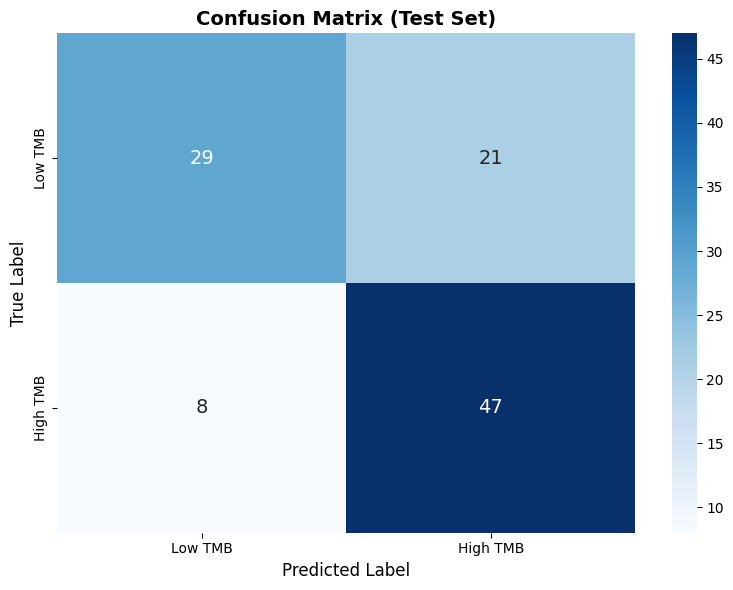

Classification Report:
              precision    recall  f1-score   support

     Low TMB       0.78      0.58      0.67        50
    High TMB       0.69      0.85      0.76        55

    accuracy                           0.72       105
   macro avg       0.74      0.72      0.72       105
weighted avg       0.74      0.72      0.72       105


Test Set Metrics:
  Precision: 0.6912
  Recall:    0.8545
  F1-Score:  0.7642


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['Low TMB', 'High TMB'],
    yticklabels=['Low TMB', 'High TMB'],
    annot_kws={'size': 14}
)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# Classification Report

print("Classification Report:")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=['Low TMB', 'High TMB']
    )
)


precision = precision_score(labels, preds)
recall = recall_score(labels,preds)
f1 = f1_score(labels,preds)

print("\nTest Set Metrics:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

## ROC Curve (Test Set)

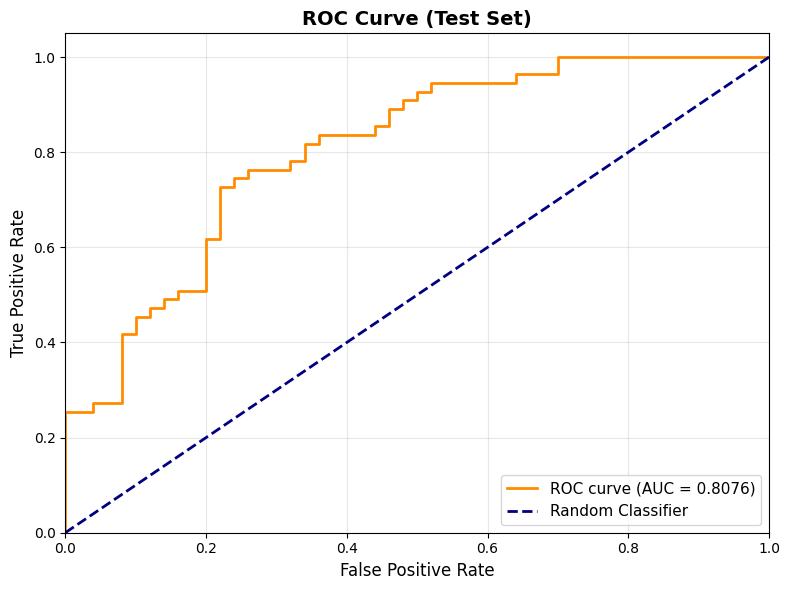

ROC AUC Score: 0.8076


In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import torch
import numpy as np

model.eval()

test_preds_final = []
test_probs_final = []
test_labels_final = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        logits = model(x)

        probs = torch.sigmoid(logits)  # IMPORTANT FIX

        preds = (probs > 0.5).float()

        test_preds_final.extend(
            preds.cpu().numpy()
        )

        test_probs_final.extend(
            probs.cpu().numpy()
        )

        test_labels_final.extend(
            y.cpu().numpy()
        )

# Convert to numpy
test_preds_final = np.array(test_preds_final).astype(int)
test_probs_final = np.array(test_probs_final)
test_labels_final = np.array(test_labels_final).astype(int)

# ROC curve
fpr, tpr, thresholds = roc_curve(
    test_labels_final,
    test_probs_final
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr, tpr,
    color='darkorange',
    lw=2,
    label=f'ROC curve (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0, 1], [0, 1],
    color='navy',
    lw=2,
    linestyle='--',
    label='Random Classifier'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)

plt.title('ROC Curve (Test Set)', fontsize=14, fontweight='bold')

plt.legend(loc="lower right", fontsize=11)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

# 8. XAI

## Attention Maps

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
images, labels = next(iter(test_loader))

image = images[0].unsqueeze(0).to(device)
label = labels[0]

print("True Label:", label.item())

True Label: 1.0


In [ ]:
model.eval()

with torch.no_grad():

    output = model(image)

    prob = torch.sigmoid(output)

    pred = (prob > 0.5).long()

print("Predicted:", pred.item())

Predicted: 1


In [ ]:
attentions = []

def get_attention_hook(module, input, output):
    # output shape: (B, num_heads, N, N)
    attentions.append(output.detach().cpu())

In [ ]:
target_block = model.layers[-1].blocks[-1].attn

hook_handle = target_block.attn_drop.register_forward_hook(get_attention_hook)

In [ ]:
image = image.view(1, 3, 224, 224)

In [ ]:
torch.Size([1, 3, 224, 224])

torch.Size([1, 3, 224, 224])

In [ ]:
model.eval()

image = image.view(1, 3, 224, 224)
with torch.no_grad():
    output = model(image)

In [ ]:
print(image.shape)

torch.Size([1, 3, 224, 224])


In [ ]:
attn = attentions[0]

attn = attn.mean(dim=1)[0]

In [ ]:
num_tokens = attn.shape[0]
size = int(np.sqrt(num_tokens))

attn_map = attn.mean(dim=0).reshape(size, size)
attn_map = attn_map.numpy()

In [ ]:
attn_map = torch.tensor(attn_map).unsqueeze(0).unsqueeze(0)
attn_map = F.interpolate(attn_map, size=(224, 224), mode='bilinear', align_corners=False)
attn_map = attn_map.squeeze().numpy()

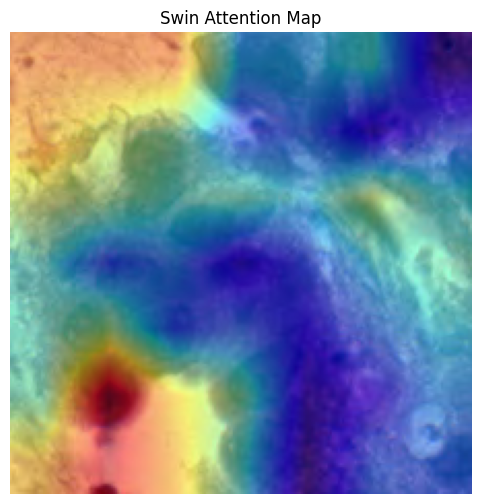

In [ ]:
img = image[0].permute(1,2,0).cpu().numpy()
img = (img - img.min()) / (img.max() - img.min())

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.imshow(attn_map, cmap='jet', alpha=0.5)
plt.title("Swin Attention Map")
plt.axis("off")
plt.show()

In [ ]:
hook_handle.remove()

## LIME

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=299553f7120771f7ef376deae71b478f8cdbd58a50033fbcd2bd25cb4515180b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import torch

In [ ]:
images, labels = next(iter(test_loader))

idx = 0
img_tensor = images[idx]
label = labels[idx]

img_np = img_tensor.permute(1,2,0).numpy()

In [ ]:
def predict(images):
    model.eval()

    images = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    images = images / 255.0

    with torch.no_grad():
        outputs = model(images)
        probs = torch.sigmoid(outputs)

    probs = probs.detach().cpu().numpy()

    # ensure shape (N, 1)
    probs = probs.reshape(-1, 1)

    # convert to 2-class format for LIME
    probs = np.concatenate([1 - probs, probs], axis=1)

    return probs

In [ ]:
print(predict(img_np[None, ...]).shape)

(1, 2)


In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

In [ ]:
explanation = explainer.explain_instance(
    img_np,              # (H, W, 3)
    predict,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

  0%|          | 0/1000 [00:00<?, ?it/s]

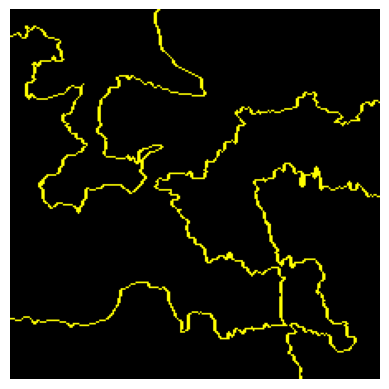

In [ ]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.axis("off")
plt.show()

In [ ]:
images, labels = next(iter(test_loader))

idx = 5
img_tensor = images[idx]
label = labels[idx]

img_np = img_tensor.permute(1,2,0).numpy()

## Occlusion Sensitivity (Sliding Patch Masking)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [ ]:
images, labels = next(iter(test_loader))

img = images[0].unsqueeze(0).to(device)
label = labels[0]

In [ ]:
model.eval()

with torch.no_grad():
    base_pred = model(img)
    base_prob = torch.sigmoid(base_pred).item()

In [ ]:
img = img.squeeze(0).to(device)

model.eval()

with torch.no_grad():
    base_pred = model(img)
    base_prob = torch.sigmoid(base_pred).item()

print(base_prob)

0.5794227719306946


In [ ]:
heatmap = occlusion(img)

In [ ]:
image_np = img[0].permute(1,2,0).cpu().numpy()
image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_np)
plt.title("Original Patch")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(image_np)
plt.imshow(heatmap, cmap="hot", alpha=0.5)
plt.title("Occlusion Heatmap")
plt.axis("off")

plt.show()